In [29]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
dataset = pd.read_csv("loan_approval_data.csv")

In [3]:
dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [4]:
dataset.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Handling Missing Values

In [5]:
float_columns = dataset.select_dtypes("float64").columns
object_columns = dataset.select_dtypes("object").columns

for column in float_columns:
    dataset[column] = dataset[column].fillna(dataset[column].mean())
    
for column in object_columns:
    dataset[column] = dataset[column].fillna(dataset[column].mode()[0])

# Explolatory Data Analysis

Text(0.5, 1.0, 'Loan Approved ?')

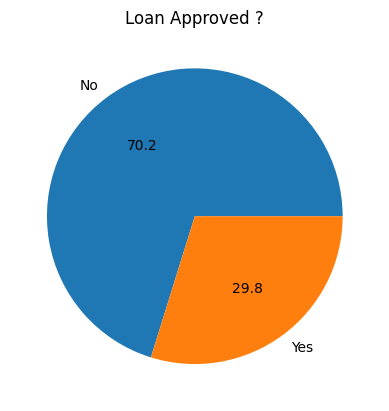

In [6]:
classes_count = dataset["Loan_Approved"].value_counts()
plt.pie(x=classes_count, labels=["No","Yes"],autopct="%.1f")
plt.title("Loan Approved ?")

Text(0.5, 1.0, 'Gender Distribution')

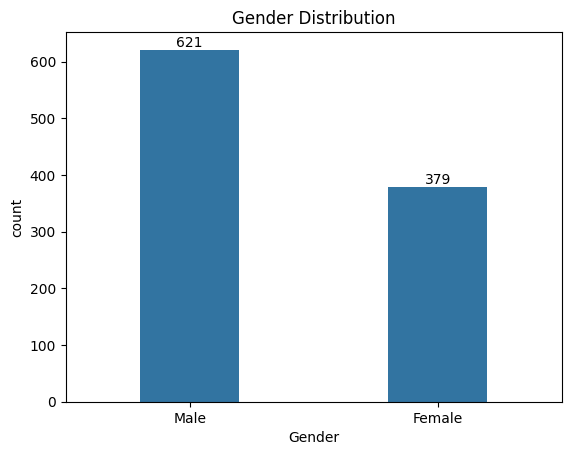

In [7]:
gender_cnt = dataset["Gender"].value_counts()
ax = sns.barplot(gender_cnt,width=.4)
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")

Text(0.5, 1.0, 'Education Level')

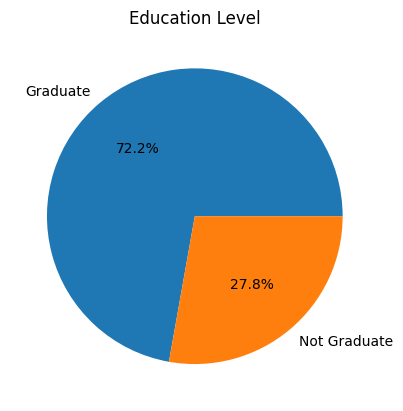

In [8]:
education_lvl_cnt = dataset["Education_Level"].value_counts()
plt.pie(education_lvl_cnt,labels=["Graduate","Not Graduate"],autopct="%1.1f%%")
plt.title("Education Level")

Text(0.5, 1.0, 'Applicant Income')

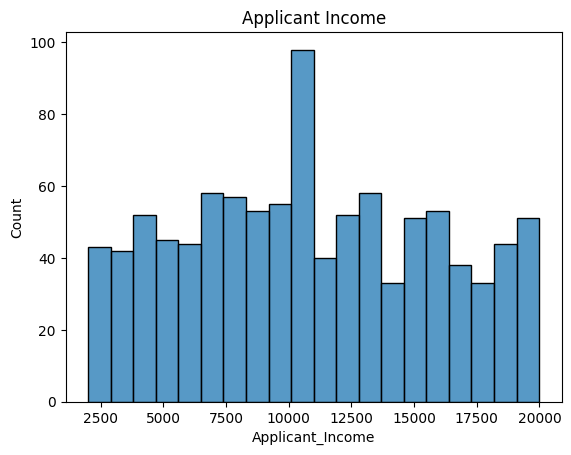

In [9]:
sns.histplot(
    data=dataset,
    x="Applicant_Income",
    bins=20
)
plt.title("Applicant Income")

Text(0.5, 1.0, 'Coapplicant Income')

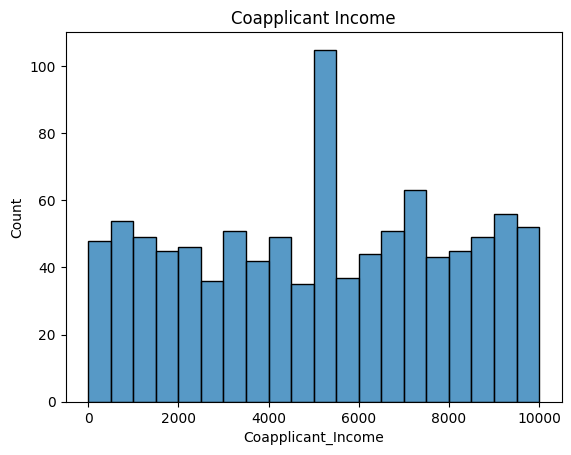

In [10]:
sns.histplot(
    data=dataset,
    x="Coapplicant_Income",
    bins=20
)
plt.title("Coapplicant Income")

Text(0.5, 1.0, 'Credit Score')

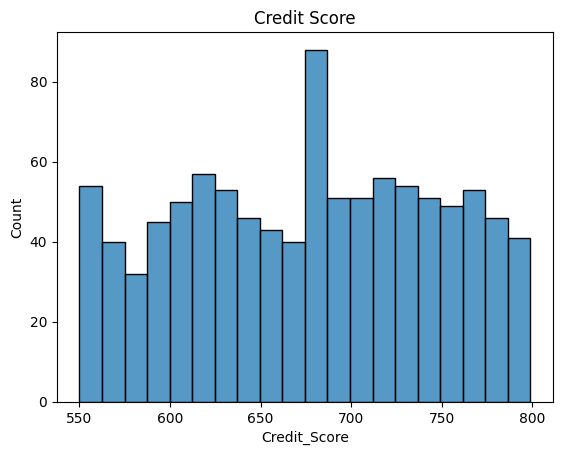

In [11]:
sns.histplot(
    data=dataset,
    x="Credit_Score",
    bins=20
)
plt.title("Credit Score")

Text(0.5, 1.0, 'Collateral Value')

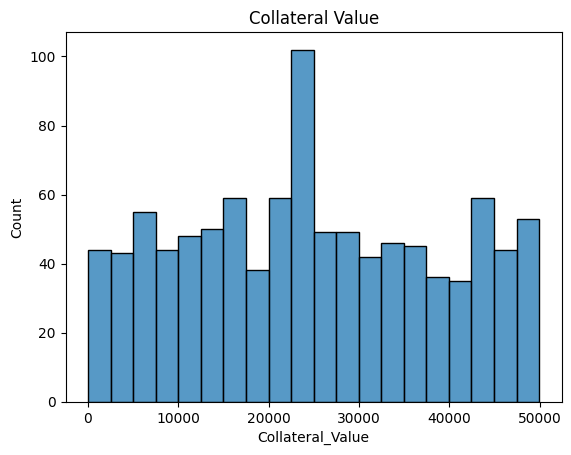

In [12]:
sns.histplot(
    data = dataset,
    x= "Collateral_Value",
    bins =20
)
plt.title("Collateral Value")

<Axes: xlabel='Credit_Score', ylabel='Count'>

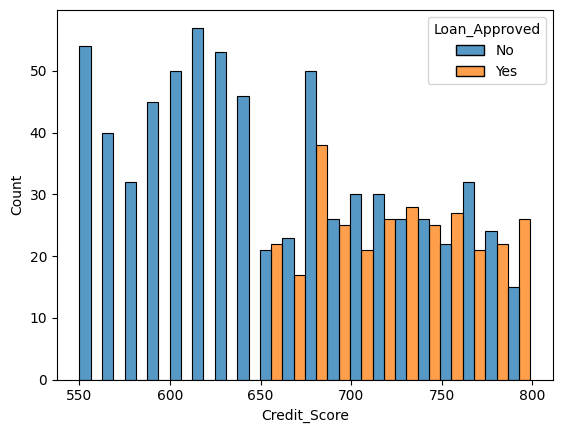

In [13]:
sns.histplot(
    data = dataset,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple ="dodge"
)

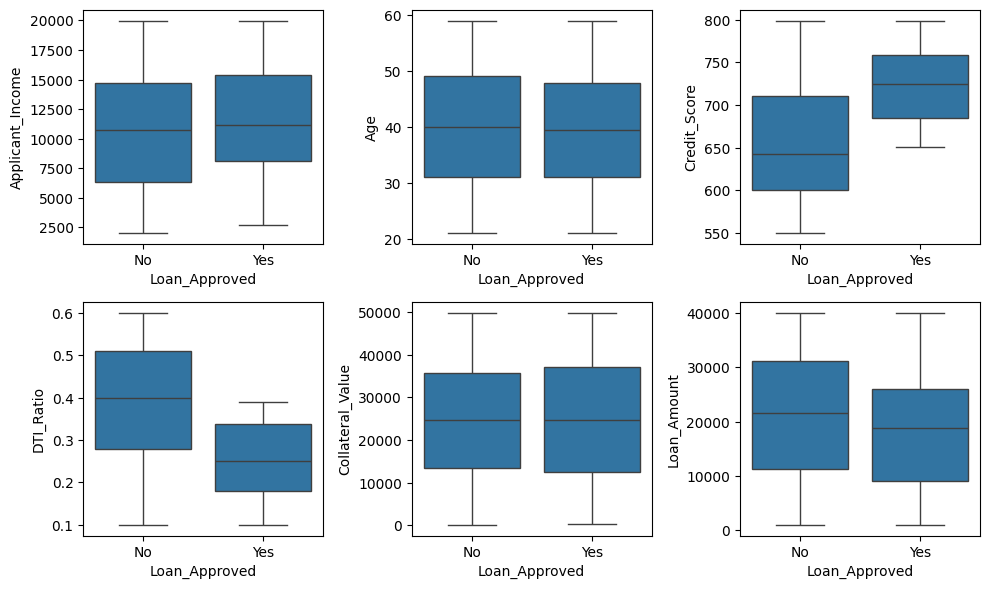

In [14]:
#Outlier Detection
fig, axs = plt.subplots(2,3,figsize=(10,6))
sns.boxplot(ax=axs[0,0],data=dataset, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axs[0,1],data=dataset, x="Loan_Approved", y="Age")
sns.boxplot(ax=axs[0,2],data=dataset, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axs[1,0],data=dataset, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axs[1,1],data=dataset, x="Loan_Approved", y="Collateral_Value")
sns.boxplot(ax=axs[1,2],data=dataset, x="Loan_Approved", y="Loan_Amount")
plt.tight_layout()

# Feature Encoding

In [15]:
le = LabelEncoder()
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

dataset["Education_Level"] = le.fit_transform(dataset["Education_Level"])
dataset["Loan_Approved"] = le.fit_transform(dataset["Loan_Approved"])

columns = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
encoded = ohe.fit_transform(dataset[columns])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(columns), index=dataset.index)

dataset = pd.concat([dataset.drop(columns=columns),encoded_df],axis=1)

In [16]:
dataset.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

<Axes: >

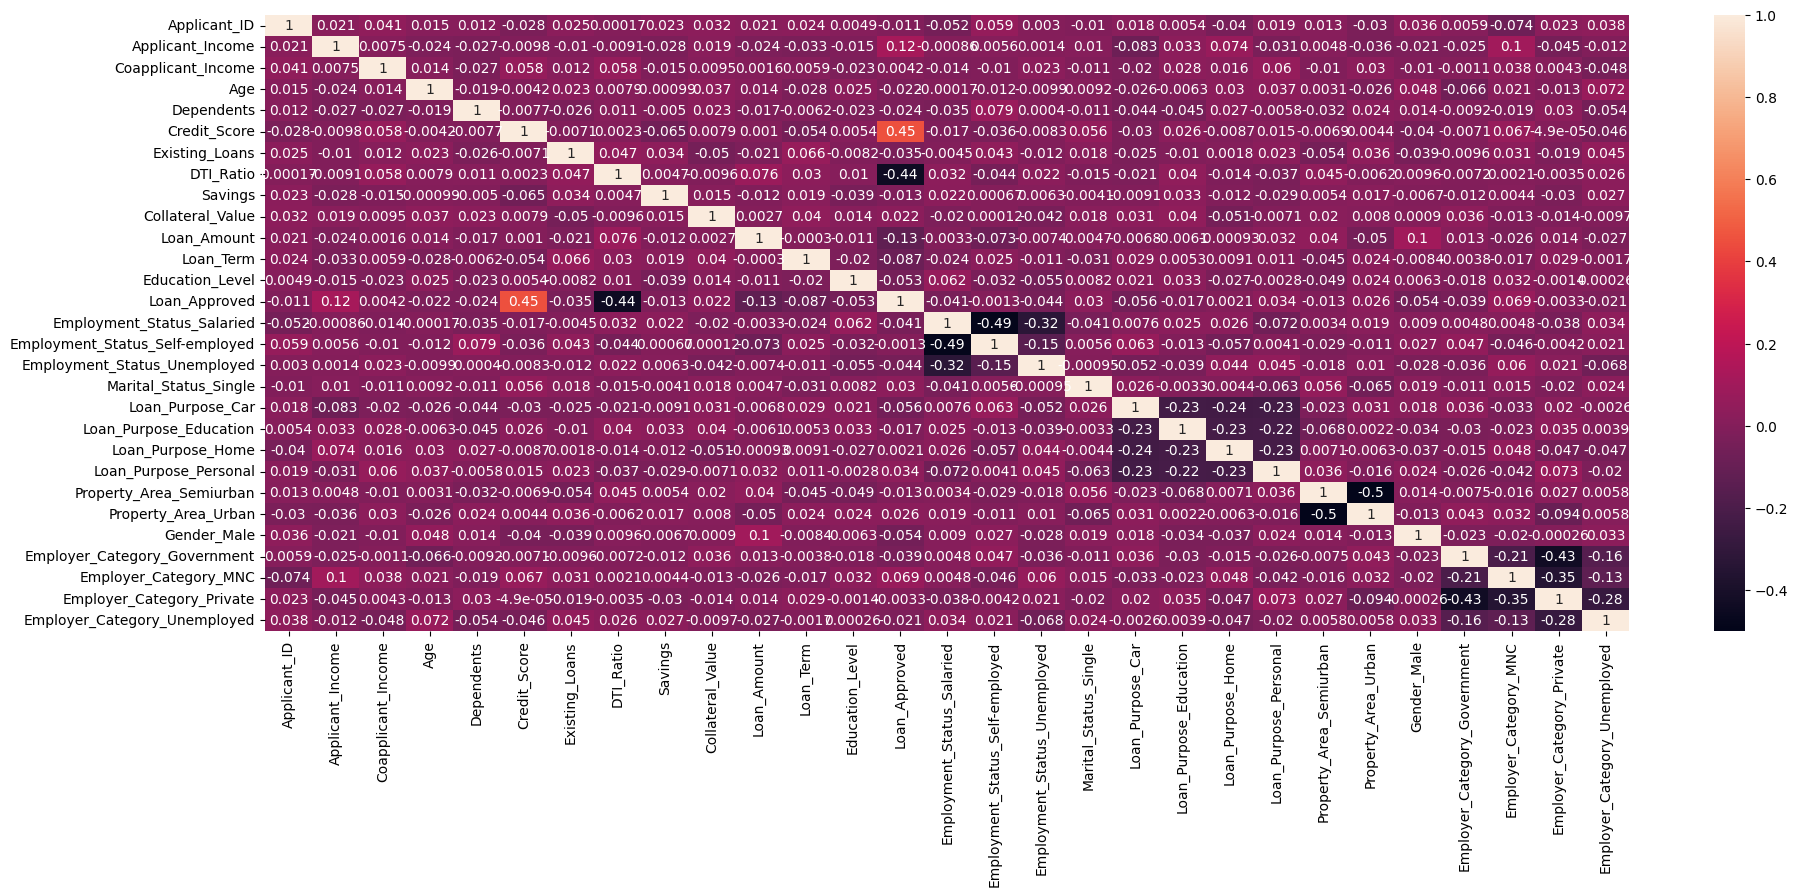

In [17]:
nums_cols = dataset.select_dtypes(include= "number")
nums_corr = nums_cols.corr()
plt.figure(figsize=(22,8))
sns.heatmap(data=nums_corr,annot=True)

# Feature Scaling

In [18]:
X = dataset.drop(columns=["Applicant_ID","Loan_Approved"])
y = dataset["Loan_Approved"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [20]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

# Training & Evaluating

In [35]:
# Logistic Regression

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_predict = log_model.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test,y_predict)}")
print(f"Recall : {recall_score(y_test,y_predict)}")
print(f"Accuracy : {accuracy_score(y_test,y_predict)}")
print(f"F1 Score : {f1_score(y_test,y_predict)}")
print(f"Confusion Matrix : {confusion_matrix(y_test,y_predict)}")


Precision : 0.7833333333333333
Recall : 0.7704918032786885
Accuracy : 0.865
F1 Score : 0.7768595041322314
Confusion Matrix : [[126  13]
 [ 14  47]]


In [34]:
# K-Nearest Neighbor
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_predict = knn_model.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test,y_predict)}")
print(f"Recall : {recall_score(y_test,y_predict)}")
print(f"Accuracy : {accuracy_score(y_test,y_predict)}")
print(f"F1 Score : {f1_score(y_test,y_predict)}")
print(f"Confusion Matrix : {confusion_matrix(y_test,y_predict)}")

Precision : 0.6274509803921569
Recall : 0.5245901639344263
Accuracy : 0.76
F1 Score : 0.5714285714285714
Confusion Matrix : [[120  19]
 [ 29  32]]


In [37]:
# Naive Bayes
bayes_model = GaussianNB()
bayes_model.fit(X_train_scaled,y_train)

y_predict = bayes_model.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test,y_predict)}")
print(f"Recall : {recall_score(y_test,y_predict)}")
print(f"Accuracy : {accuracy_score(y_test,y_predict)}")
print(f"F1 Score : {f1_score(y_test,y_predict)}")
print(f"Confusion Matrix : {confusion_matrix(y_test,y_predict)}")

Precision : 0.8035714285714286
Recall : 0.7377049180327869
Accuracy : 0.865
F1 Score : 0.7692307692307693
Confusion Matrix : [[128  11]
 [ 16  45]]
